Michel Spectrum Subtraction

In [1]:
import numpy as np
import matplotlib.pyplot as plt

file1 = '/raid1/genli/Data_D2O/M1_data/analysis_24531-24585_M1_20250730-193838/MASTER_RESULTS/Master_Runs_24531_24585_M1_total_pe.pkl'
file2 = '/raid1/genli/Data_D2O/M2_data/analysis_396-450_M2_20250730-195909/MASTER_RESULTS/Master_Runs_396_450_M2_total_pe.pkl'

data1 = np.load(file1, allow_pickle=True)
data2 = np.load(file2, allow_pickle=True)

print(data1)

centers1 = data1['centers']
centers2 = data2['centers']
sum_area1 = data1['hist']
sum_area2 = data2['hist']
err1 = data1['errors']
err2 = data2['errors']

{'centers': array([  10.,   30.,   50.,   70.,   90.,  110.,  130.,  150.,  170.,
        190.,  210.,  230.,  250.,  270.,  290.,  310.,  330.,  350.,
        370.,  390.,  410.,  430.,  450.,  470.,  490.,  510.,  530.,
        550.,  570.,  590.,  610.,  630.,  650.,  670.,  690.,  710.,
        730.,  750.,  770.,  790.,  810.,  830.,  850.,  870.,  890.,
        910.,  930.,  950.,  970.,  990., 1010., 1030., 1050., 1070.,
       1090., 1110., 1130., 1150., 1170., 1190., 1210., 1230., 1250.,
       1270., 1290., 1310., 1330., 1350., 1370., 1390., 1410., 1430.,
       1450., 1470., 1490., 1510., 1530., 1550., 1570., 1590., 1610.,
       1630., 1650., 1670., 1690., 1710., 1730., 1750., 1770., 1790.,
       1810., 1830., 1850., 1870., 1890., 1910., 1930., 1950., 1970.,
       1990.]), 'hist': array([  392, 12921, 36483, 43763, 47797, 50539, 51312, 50150, 46465,
       39586, 31698, 25057, 20015, 15723, 12906, 10403,  8478,  6824,
        5437,  4476,  3744,  3110,  2609,  2148,  1808

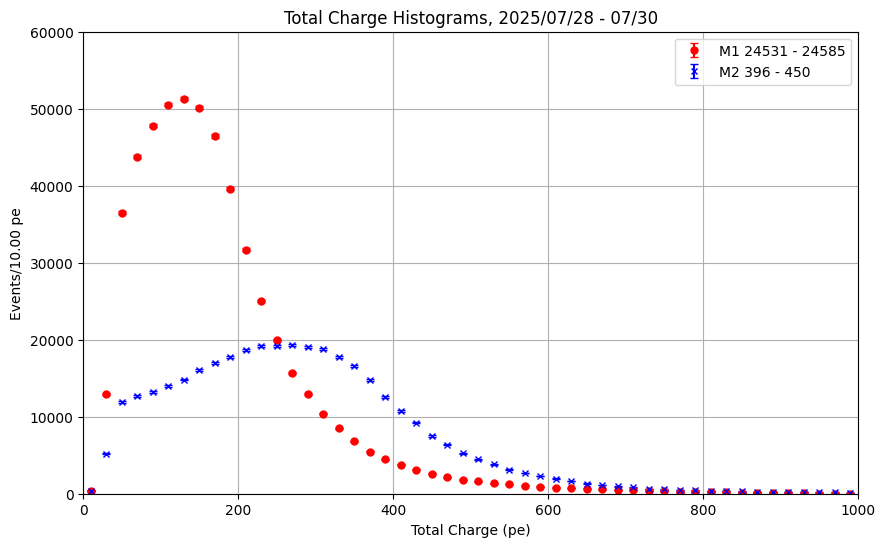

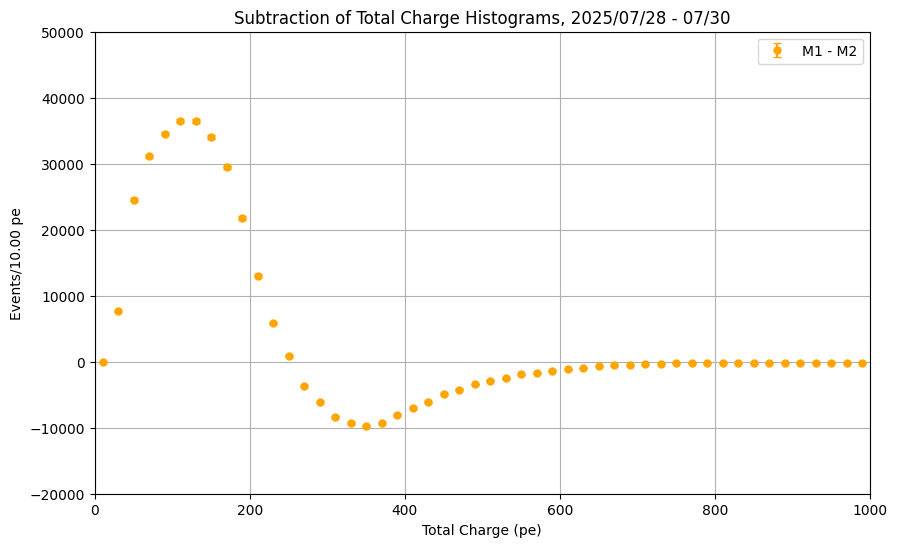

In [2]:
#Normalize the histograms and errors
# Convert to float to avoid casting errors
sum_area1 = sum_area1.astype(float)
sum_area2 = sum_area2.astype(float)
err1 = err1.astype(float)
err2 = err2.astype(float)
err_total = np.sqrt(err1**2 + err2**2)
bin_step = 1000 / centers1.size  # Assuming centers1 and centers2 have the same size
#plotting hist1 and hist2 on the same plot
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, sum_area1, yerr=err1, fmt='o', label='M1 24531 - 24585', color='red', markersize=5, capsize=3)
plt.errorbar(centers2, sum_area2, yerr=err2, fmt='x', label='M2 396 - 450', color='blue', markersize=5, capsize=3)
plt.title('Total Charge Histograms, 2025/07/28 - 07/30')
plt.xlabel('Total Charge (pe)')
plt.ylabel(f'Events/{bin_step:.2f} pe')  # Adjusted ylabel to include bin step
plt.ylim(0, 60000)
plt.xlim(0, 1000)
plt.legend()
plt.grid()
# plt.savefig('total_charge_histograms.png')
plt.show()

#plotting subtraction hist1 - hist2
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, sum_area1 - sum_area2, yerr=err_total, fmt='o', label='M1 - M2', color='orange', markersize=5, capsize=3)
plt.title('Subtraction of Total Charge Histograms, 2025/07/28 - 07/30')
plt.xlabel('Total Charge (pe)')
plt.ylabel(f'Events/{bin_step:.2f} pe')  # Adjusted ylabel to include bin step
plt.ylim(-20000, 50000)
plt.xlim(0, 1000)
plt.legend()
plt.grid()
# plt.savefig('subtraction_histograms.png')
plt.show()

In [3]:
print("M1 events number:", np.sum(sum_area1))
print("M2 events number:", np.sum(sum_area2))
print("Subtraction events number:", np.sum(sum_area1 - sum_area2))

M1 events number: 545652.0
M2 events number: 368174.0
Subtraction events number: 177478.0


Muon veto efficiency

{'centers': array([  50.,  150.,  250.,  350.,  450.,  550.,  650.,  750.,  850.,
        950., 1050., 1150., 1250., 1350., 1450., 1550., 1650., 1750.,
       1850., 1950.]), 'efficiency': array([0.80890487, 0.82716414, 0.90240366, 0.94800304, 0.97074296,
       0.97310311, 0.97593698, 0.96943441, 0.9792719 , 0.99888687,
       0.99941951, 0.99954399, 0.99963702, 0.99974539, 0.99975521,
       0.99981563, 0.99984999, 0.99984511, 0.99992108, 0.99986152]), 'error': array([3.71752075e-04, 2.95226074e-04, 2.44000644e-04, 1.82165994e-04,
       1.39578297e-04, 1.34190206e-04, 1.25041695e-04, 1.36873909e-04,
       1.13684791e-04, 2.77090939e-05, 2.14491913e-05, 2.09183790e-05,
       2.07466321e-05, 1.93551059e-05, 2.08353402e-05, 1.95414989e-05,
       1.92056814e-05, 2.16877149e-05, 1.76455295e-05, 2.76935431e-05]), 'counts_2': array([213742, 283498, 144373,  77238,  42651,  39095,  36142,  48344,
        32555,   1612,    732,    475,    306,    173,    138,     89,
           61,     51

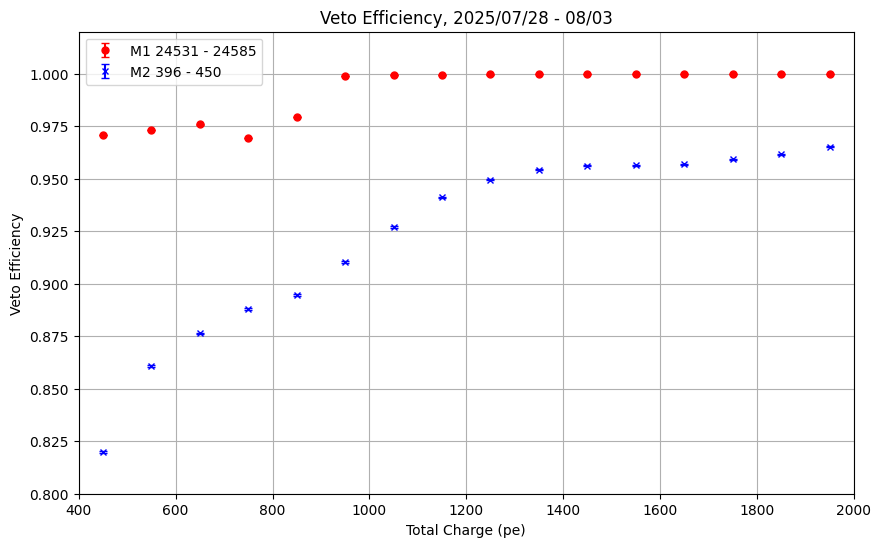

In [4]:
m1_file = '/raid1/genli/Data_D2O/M1_data/analysis_24531-24585_M1_20250730-193838/MASTER_RESULTS/Master_Runs_24531_24585_M1_veto_efficiency_master.pkl'
m2_file = '/raid1/genli/Data_D2O/M2_data/analysis_396-450_M2_20250730-195909/MASTER_RESULTS/Master_Runs_396_450_M2_veto_efficiency_master.pkl'
m1_data = np.load(m1_file, allow_pickle=True)
m2_data = np.load(m2_file, allow_pickle=True)

print(m1_data)
centers1 = m1_data['centers']
centers2 = m2_data['centers']
veto_eff1 = m1_data['efficiency']
veto_eff2 = m2_data['efficiency']
err1 = m1_data['error']
err2 = m2_data['error']

#plotting veto efficiency
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, veto_eff1, yerr=err1, fmt='o', label='M1 24531 - 24585', color='red', markersize=5, capsize=3)
plt.errorbar(centers2, veto_eff2, yerr=err2, fmt='x', label='M2 396 - 450', color='blue', markersize=5, capsize=3)
plt.title('Veto Efficiency, 2025/07/28 - 08/03')
plt.xlabel('Total Charge (pe)')
plt.ylabel('Veto Efficiency')
plt.ylim(0.8, 1.02)
plt.xlim(400, 2000)
plt.legend()
plt.grid()
# plt.savefig('veto_efficiency.png')
plt.show()

{'centers': array([  50.,  150.,  250.,  350.,  450.,  550.,  650.,  750.,  850.,
        950., 1050., 1150., 1250., 1350., 1450., 1550., 1650., 1750.,
       1850., 1950.]), 'efficiency': array([0.51062736, 0.70042709, 0.72382759, 0.76013942, 0.81810771,
       0.85796155, 0.87337703, 0.89003322, 0.89856856, 0.90889703,
       0.92647548, 0.93951026, 0.95305529, 0.95340412, 0.95848104,
       0.95769922, 0.95931618, 0.96078793, 0.96312066, 0.96452199]), 'error': array([0.00302873, 0.00292144, 0.00311845, 0.003103  , 0.0029435 ,
       0.00274034, 0.00264012, 0.00255015, 0.0024297 , 0.00234912,
       0.00212896, 0.00193936, 0.00170089, 0.00166578, 0.00154632,
       0.00155798, 0.00152473, 0.00152287, 0.00152535, 0.00157727]), 'counts_2': array([13331,  7365,  5677,  4542,  3124,  2305,  2009,  1655,  1566,
        1367,  1105,   914,   726,   746,   691,   706,   683,   637,
         563,   488]), 'counts_2_or_34': array([27241, 24585, 20556, 18936, 17175, 16228, 15866, 15050, 15439,

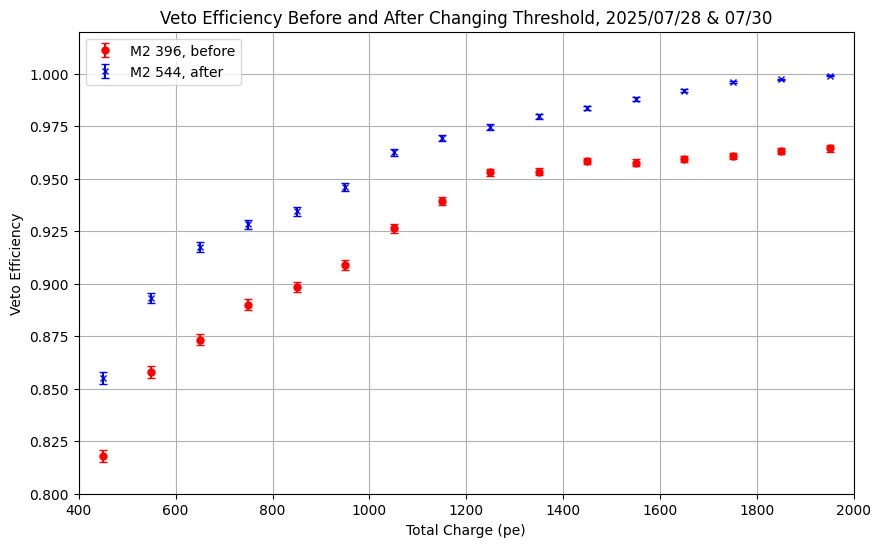

In [5]:
file1 = '/raid1/genli/Data_D2O/M2_data/analysis_396-397_M2_20250804-160852/subjob_396-396/run396_20250728-08/histograms/396_M2_veto_efficiency.pkl'
file2 = '/raid1/genli/Data_D2O/M2_data/analysis_544-545_M2_20250804-160336/subjob_544-544/run544_20250803-13/histograms/544_M2_veto_efficiency.pkl'
data1 = np.load(file1, allow_pickle=True)
data2 = np.load(file2, allow_pickle=True)

print(data1)
centers1 = data1['centers']
centers2 = data2['centers']
veto_eff1 = data1['efficiency']
veto_eff2 = data2['efficiency']
err1 = data1['error']
err2 = data2['error']

#plotting veto efficiency
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, veto_eff1, yerr=err1, fmt='o', label='M2 396, before', color='red', markersize=5, capsize=3)
plt.errorbar(centers2, veto_eff2, yerr=err2, fmt='x', label='M2 544, after', color='blue', markersize=5, capsize=3)
plt.title('Veto Efficiency Before and After Changing Threshold, 2025/07/28 & 07/30')
plt.xlabel('Total Charge (pe)')
plt.ylabel('Veto Efficiency')
plt.ylim(0.8, 1.02)
plt.xlim(400, 2000)
plt.legend()
plt.grid()
# plt.savefig('veto_efficiency.png')
plt.show()

Trigger Bits

{'centers': array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
       11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
       22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
       33.5, 34.5]), 'histograms': {'triggerBits': array([8.20000e+02, 0.00000e+00, 9.21949e+05, 0.00000e+00, 2.15711e+05,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 2.15702e+05, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 2.15697e+05, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 6.80910e+05, 0.00000e+00, 4.05039e+05])}}


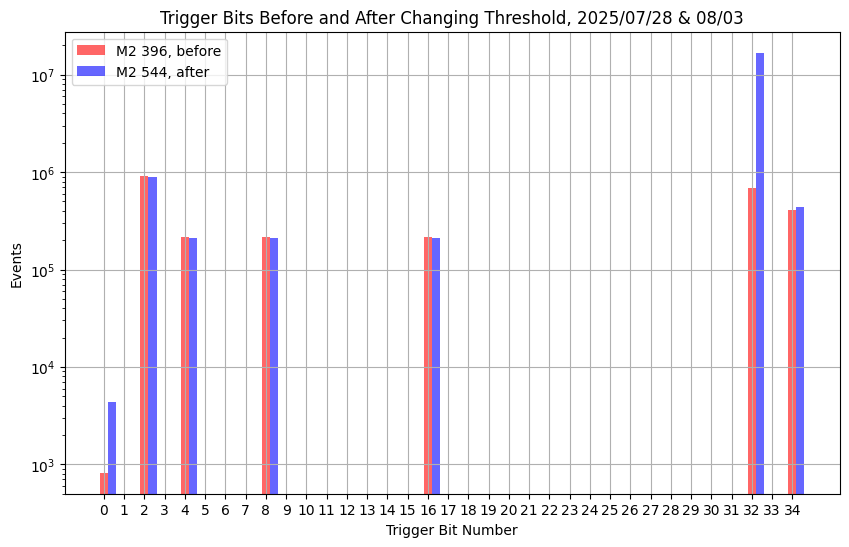

In [6]:
file1_triggerbit = '/raid1/genli/Data_D2O/M2_data/analysis_396-397_M2_20250804-160852/subjob_396-396/run396_20250728-08/histograms/396_M2_triggerBits.pkl'
file2_triggerbit = '/raid1/genli/Data_D2O/M2_data/analysis_544-545_M2_20250804-160336/subjob_544-544/run544_20250803-13/histograms/544_M2_triggerBits.pkl'
triggerbit1 = np.load(file1_triggerbit, allow_pickle=True)
triggerbit2 = np.load(file2_triggerbit, allow_pickle=True)
print(triggerbit1)
centers1_trigger = triggerbit1['centers']
centers2_trigger = triggerbit2['centers']
triggerbit1_hist = triggerbit1['histograms']['triggerBits']
triggerbit2_hist = triggerbit2['histograms']['triggerBits']

#plotting trigger bits
plt.figure(figsize=(10, 6))
#x axis is the trigger bit number
triggerbits = list(range(0,35))
plt.bar(triggerbits, triggerbit1_hist, width=0.4, label='M2 396, before', color='red', alpha=0.6, align='center')
plt.bar(np.array(triggerbits) + 0.4, triggerbit2_hist, width=0.4, label='M2 544, after', color='blue', alpha=0.6, align='center')
plt.title('Trigger Bits Before and After Changing Threshold, 2025/07/28 & 08/03')
plt.xlabel('Trigger Bit Number')
plt.ylabel('Events')
plt.xticks(np.arange(0, 35, 1))
plt.yscale('log', base=10)  # Use logarithmic scale for better visibility
# plt.ylim(0, 100000)
plt.legend()
plt.grid()
# plt.savefig('trigger_bits.png')
plt.show()

Thin Panel Troubleshooting

{'centers': array([  25.,   75.,  125.,  175.,  225.,  275.,  325.,  375.,  425.,
        475.,  525.,  575.,  625.,  675.,  725.,  775.,  825.,  875.,
        925.,  975., 1025., 1075., 1125., 1175., 1225., 1275., 1325.,
       1375., 1425., 1475., 1525., 1575., 1625., 1675., 1725., 1775.,
       1825., 1875., 1925., 1975., 2025., 2075., 2125., 2175., 2225.,
       2275., 2325., 2375., 2425., 2475., 2525., 2575., 2625., 2675.,
       2725., 2775., 2825., 2875., 2925., 2975., 3025., 3075., 3125.,
       3175., 3225., 3275., 3325., 3375., 3425., 3475., 3525., 3575.,
       3625., 3675., 3725., 3775., 3825., 3875., 3925., 3975., 4025.,
       4075., 4125., 4175., 4225., 4275., 4325., 4375., 4425., 4475.,
       4525., 4575., 4625., 4675., 4725., 4775., 4825., 4875., 4925.,
       4975.]), 'histograms': {'Muon Events (Coincidence)': array([4.33343364e-05, 1.21175644e-04, 2.39542582e-04, 4.13949911e-04,
       9.26070820e-04, 1.54465510e-03, 2.13809476e-03, 2.16390812e-03,
       1.8009161

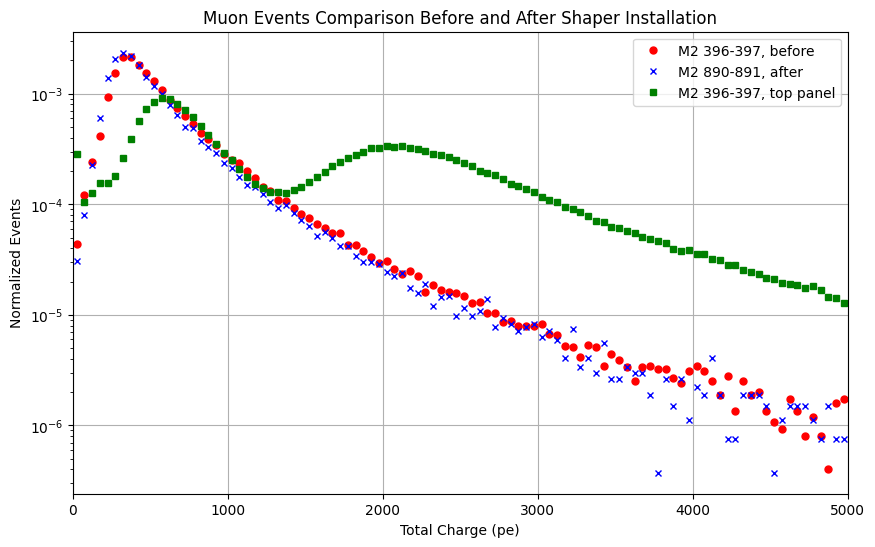

In [11]:
#comapre before and after shaper, also compare with top panel
data_area_before = '/raid1/genli/Data_D2O/M2_data/analysis_396-397_M2_20250820-220724/MASTER_RESULTS/Master_Runs_396_397_M2_thin_veto_area_comparison_master.pkl'
data_area_after = '/raid1/genli/Data_D2O/M2_data/analysis_890-891_M2_20250819-213833/MASTER_RESULTS/Master_Runs_890_891_M2_thin_veto_area_comparison_master.pkl'
data_area_top = '/raid1/genli/Data_D2O/M2_data/analysis_396-397_M2_20250820-220918/MASTER_RESULTS/Master_Runs_396_397_M2_thin_veto_area_comparison_master.pkl'

# Load the data
area_before = np.load(data_area_before, allow_pickle=True)
area_after = np.load(data_area_after, allow_pickle=True)
area_top = np.load(data_area_top, allow_pickle=True)

print(area_before)
centers = area_before['centers']
muon_before = area_before['histograms']['Muon Events (Coincidence)']
muon_after = area_after['histograms']['Muon Events (Coincidence)']
muon_top = area_top['histograms']['Muon Events (Coincidence)']

# Plotting the muon events before, after, and top panel
plt.figure(figsize=(10, 6))
plt.errorbar(centers, muon_before, fmt='o', label='M2 396-397, before', color='red', markersize=5, capsize=3)
plt.errorbar(centers, muon_after, fmt='x', label='M2 890-891, after', color='blue', markersize=5, capsize=3)
plt.errorbar(centers, muon_top, fmt='s', label='M2 396-397, top panel', color='green', markersize=5, capsize=3)
plt.title('Muon Events Comparison Before and After Shaper Installation')
plt.xlabel('Total Charge (pe)') 
plt.ylabel('Normalized Events')
plt.xlim(0, 5000)
plt.yscale('log', base=10)
plt.legend()
plt.grid()
# plt.savefig('muon_events_comparison.png')
plt.show()

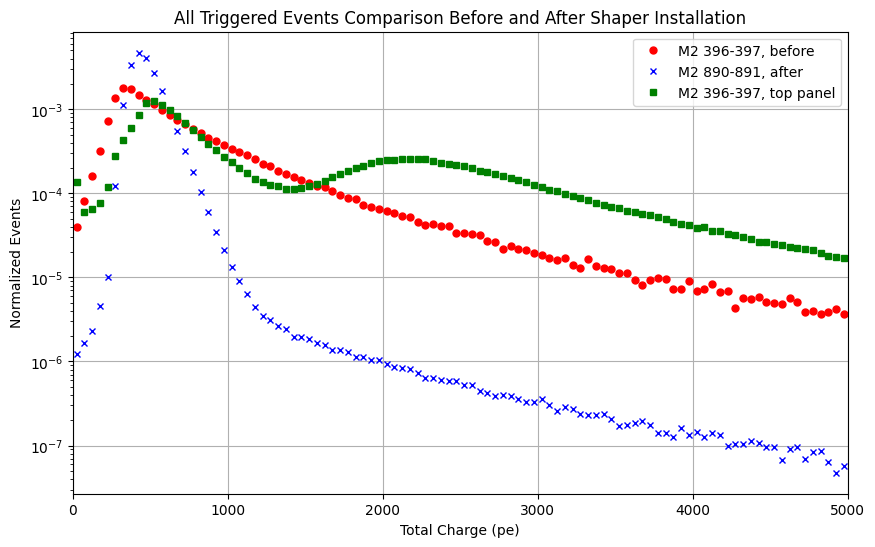

In [12]:
All_before = area_before['histograms']['All Triggered Events']
All_after = area_after['histograms']['All Triggered Events']
All_top = area_top['histograms']['All Triggered Events']

# Plotting the All events before, after, and top panel
plt.figure(figsize=(10, 6))
plt.errorbar(centers, All_before, fmt='o', label='M2 396-397, before', color='red', markersize=5, capsize=3)
plt.errorbar(centers, All_after, fmt='x', label='M2 890-891, after', color='blue', markersize=5, capsize=3)
plt.errorbar(centers, All_top, fmt='s', label='M2 396-397, top panel', color='green', markersize=5, capsize=3)
plt.title('All Triggered Events Comparison Before and After Shaper Installation')
plt.xlabel('Total Charge (pe)') 
plt.ylabel('Normalized Events')
plt.xlim(0, 5000)
plt.yscale('log', base=10)
plt.legend()
plt.grid()
# plt.savefig('All_events_comparison.png')
plt.show()

{'centers': array([  50.,  150.,  250.,  350.,  450.,  550.,  650.,  750.,  850.,
        950., 1050., 1150., 1250., 1350., 1450., 1550., 1650., 1750.,
       1850., 1950.]), 'efficiency': array([0.80878454, 0.82698606, 0.90233296, 0.94780673, 0.97068238,
       0.97301988, 0.97595439, 0.96947183, 0.97928091, 0.99887776,
       0.99938906, 0.99953698, 0.99963378, 0.99971614, 0.9997254 ,
       0.99982986, 0.99983657, 0.99988002, 0.99992494, 0.99991219]), 'error': array([4.67507863e-04, 3.71514589e-04, 3.06897949e-04, 2.29568265e-04,
       1.75727858e-04, 1.69017395e-04, 1.57168110e-04, 1.72064104e-04,
       1.42919386e-04, 3.49992006e-05, 2.76759901e-05, 2.65065044e-05,
       2.62206491e-05, 2.56961479e-05, 2.77348821e-05, 2.35925251e-05,
       2.52163990e-05, 2.39941069e-05, 2.16659366e-05, 2.77655819e-05]), 'counts_2': array([135301, 179353,  91385,  48992,  27018,  24794,  22844,  30518,
        20581,   1027,    487,    305,    195,    122,     98,     52,
           42,     25

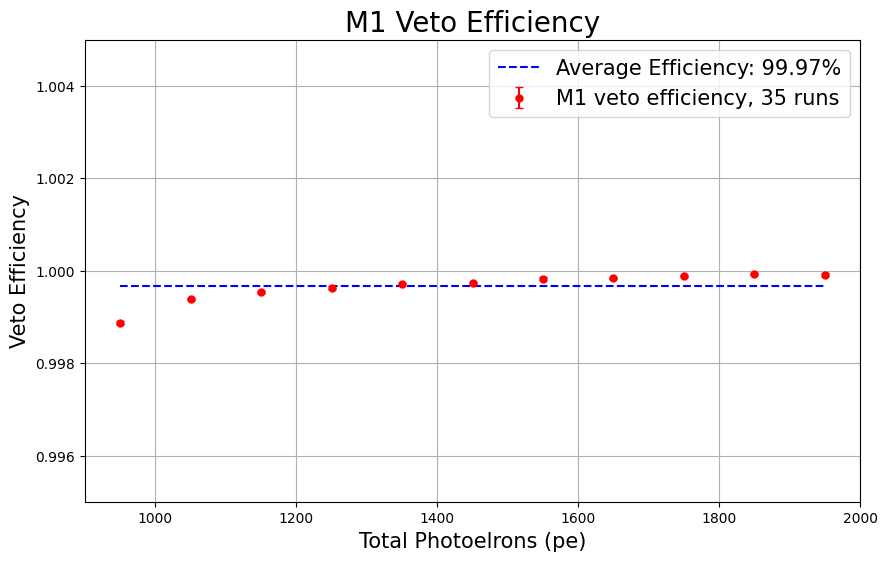

In [15]:
import numpy as np
import matplotlib.pyplot as plt
#load /raid1/genli/Data_D2O/M1_data/analysis_24531-24565_M1_20251017-180538/MASTER_RESULTS/Master_Runs_24531_24565_M1_veto_efficiency_master.pkl
efficplotpath = '/raid1/genli/Data_D2O/M1_data/analysis_24531-24565_M1_20251017-180538/MASTER_RESULTS/Master_Runs_24531_24565_M1_veto_efficiency_master.pkl'
data_eff = np.load(efficplotpath, allow_pickle=True)
print(data_eff)
#make a mask with centers > 1000
mask = data_eff['centers'] > 900
centers_eff = data_eff['centers'][mask]
veto_eff = data_eff['efficiency'][mask]
err_eff = data_eff['error'][mask]
average_eff = np.mean(veto_eff)
#plotting veto efficiency
plt.figure(figsize=(10, 6))
plt.errorbar(centers_eff, veto_eff, yerr=err_eff, fmt='o', label='M1 veto efficiency, 35 runs', color='red', markersize=5, capsize=3)
plt.hlines(average_eff, xmin=centers_eff[0], xmax=centers_eff[-1], colors='blue', linestyles='dashed', label=f'Average Efficiency: {100*average_eff:.2f}%')
plt.title('M1 Veto Efficiency', fontsize=20)
plt.xlabel('Total Photoelrons (pe)', fontsize=15)
plt.ylabel('Veto Efficiency', fontsize=15)
plt.ylim(0.995, 1.005)
plt.legend(fontsize=15)
plt.grid()





Lead Background Analysis

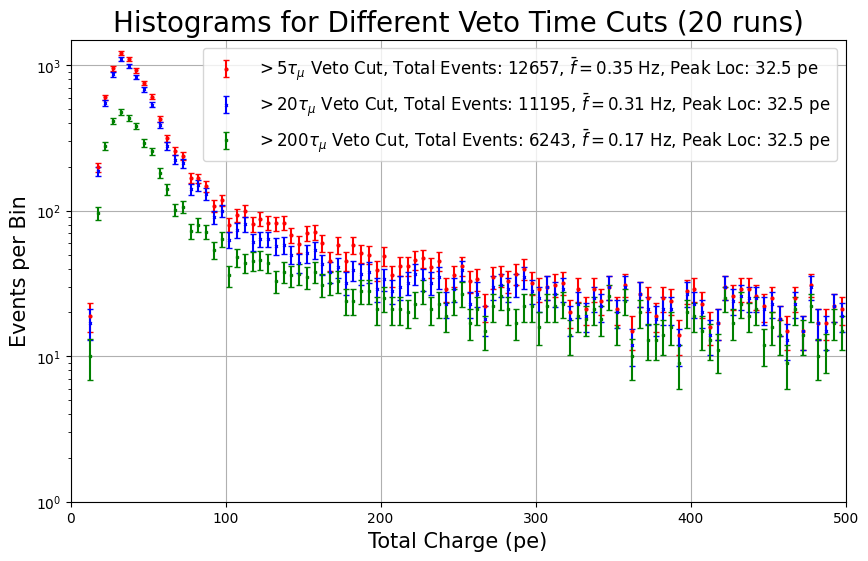

/tmp/ipykernel_346305/910871761.py:48: RuntimeWarning: divide by zero encountered in divide
  ratio_5tau_200tau = numpe_5tau / numpe_200tau
/tmp/ipykernel_346305/910871761.py:48: RuntimeWarning: invalid value encountered in divide
  ratio_5tau_200tau = numpe_5tau / numpe_200tau
/tmp/ipykernel_346305/910871761.py:50: RuntimeWarning: invalid value encountered in divide
  ratio_err_5tau_200tau = ratio_5tau_200tau * np.sqrt((err_5tau / numpe_5tau) ** 2 + (err_200tau / numpe_200tau) ** 2)


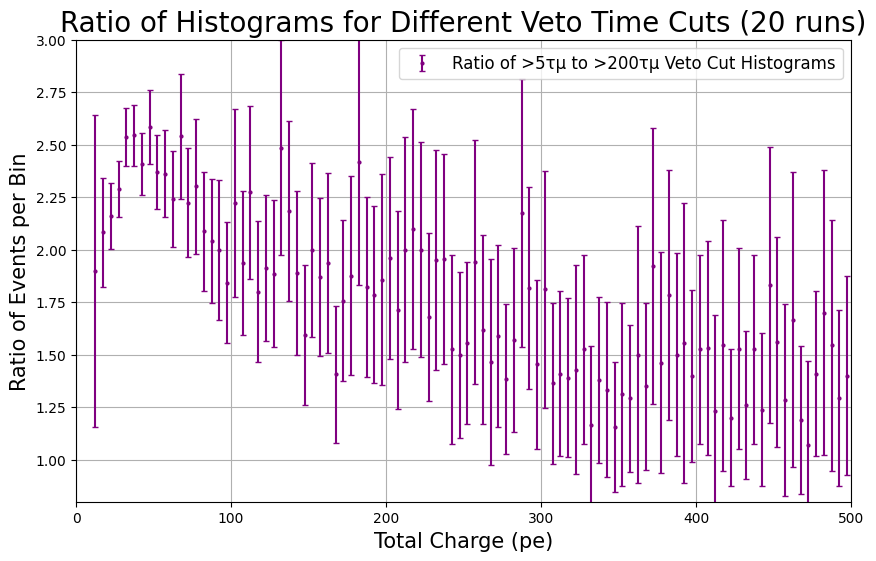

In [ ]:

#Apply different long dt cuts and plot the histograms. 
#After apply that, since it happens from 06/01/2025, so it is in beam-off period and only non-beam background events are expected.
import numpy as np
import matplotlib.pyplot as plt

file_5tau = '/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251113-092331_5tau/MASTER_RESULTS/aggregated_total_pe_M1.pkl'
data_5tau = np.load(file_5tau, allow_pickle=True)
file_20tau = '/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251113-091825_20tau/MASTER_RESULTS/aggregated_total_pe_M1.pkl'
data_20tau = np.load(file_20tau, allow_pickle=True)
file_200tau = '/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251113-091102_200tau/MASTER_RESULTS/aggregated_total_pe_M1.pkl'
data_200tau = np.load(file_200tau, allow_pickle=True)

centers_5tau = data_5tau['centers']
numpe_5tau = data_5tau['histograms']['Master Runs 23163-23172']
err_5tau = data_5tau['errors']['Master Runs 23163-23172']
centers_20tau = data_20tau['centers']
numpe_20tau = data_20tau['histograms']['Master Runs 23163-23172']
err_20tau = data_20tau['errors']['Master Runs 23163-23172']
centers_200tau = data_200tau['centers']
numpe_200tau = data_200tau['histograms']['Master Runs 23163-23172']
err_200tau = data_200tau['errors']['Master Runs 23163-23172']

total_events_5tau = np.sum(numpe_5tau)
total_events_20tau = np.sum(numpe_20tau)
total_events_200tau = np.sum(numpe_200tau)

peakloc_5tau = centers_5tau[np.argmax(numpe_5tau)]
peakloc_20tau = centers_20tau[np.argmax(numpe_20tau)]
peakloc_200tau = centers_200tau[np.argmax(numpe_200tau)]

# print(data_5tau)
#Plotting the histograms for different dt cuts
plt.figure(figsize=(10, 6))
plt.errorbar(centers_5tau, numpe_5tau, yerr=err_5tau, fmt='o', label=f'$>5 \\tau_\\mu$ Veto Cut, Total Events: {total_events_5tau}, $\\bar{{f}} = {total_events_5tau/36000:.2f}$ Hz, Peak Loc: {peakloc_5tau} pe', color='red', markersize=2, capsize=2)
plt.errorbar(centers_20tau, numpe_20tau, yerr=err_20tau, fmt='x', label=f'$>20 \\tau_\\mu$ Veto Cut, Total Events: {total_events_20tau}, $\\bar{{f}} = {total_events_20tau/36000:.2f}$ Hz, Peak Loc: {peakloc_20tau} pe', color='blue', markersize=2, capsize=2)
plt.errorbar(centers_200tau, numpe_200tau, yerr=err_200tau, fmt='s', label=f'$>200 \\tau_\\mu$ Veto Cut, Total Events: {total_events_200tau}, $\\bar{{f}} = {total_events_200tau/36000:.2f}$ Hz, Peak Loc: {peakloc_200tau} pe', color='green', markersize=2, capsize=2)
plt.title('Histograms for Different Veto Time Cuts (20 runs)', fontsize=20)
plt.xlabel('Total Charge (pe)', fontsize=15)
plt.ylabel('Events per Bin', fontsize=15)
plt.yscale('log', base=10)
plt.xlim(0, 500)
plt.ylim(1, 1.5e3)
plt.legend(fontsize=12)
plt.grid()
plt.show()

#Plot divide 5tau histogram by 200tau histogram, recalculate the errors
ratio_5tau_200tau = numpe_5tau / numpe_200tau
# Recalculate the errors for the ratio
ratio_err_5tau_200tau = ratio_5tau_200tau * np.sqrt((err_5tau / numpe_5tau) ** 2 + (err_200tau / numpe_200tau) ** 2)
#Plotting the ratio
plt.figure(figsize=(10, 6))
plt.errorbar(centers_5tau, ratio_5tau_200tau, yerr=ratio_err_5tau_200tau, fmt='o', label='Ratio of >5τμ to >200τμ Veto Cut Histograms', color='purple', markersize=2, capsize=2)
plt.title('Ratio of Histograms for Different Veto Time Cuts (10 runs)', fontsize=20)
plt.xlabel('Total Charge (pe)', fontsize=15)
plt.ylabel('Ratio of Events per Bin', fontsize=15)
plt.xlim(0, 500)
plt.ylim(0.8, 3)
plt.legend(fontsize=12)
plt.grid()
plt.show()
# plt.savefig('M1_veto_efficiency.png')

Time without top lead: 35979.74 seconds
Time with top lead: 35969.96 seconds


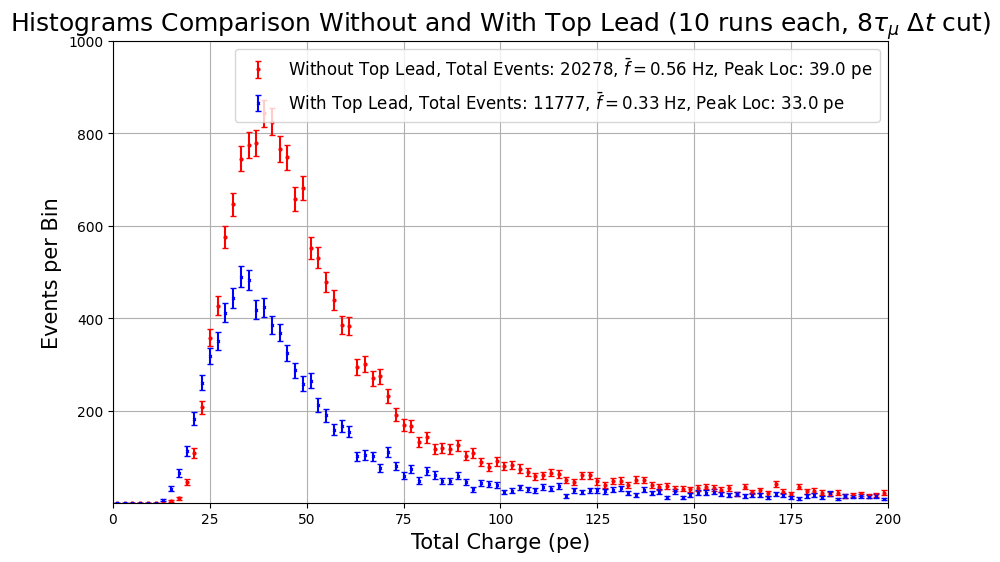

Runs without top lead: 14977-14986
Runs with top lead: 23163-23172


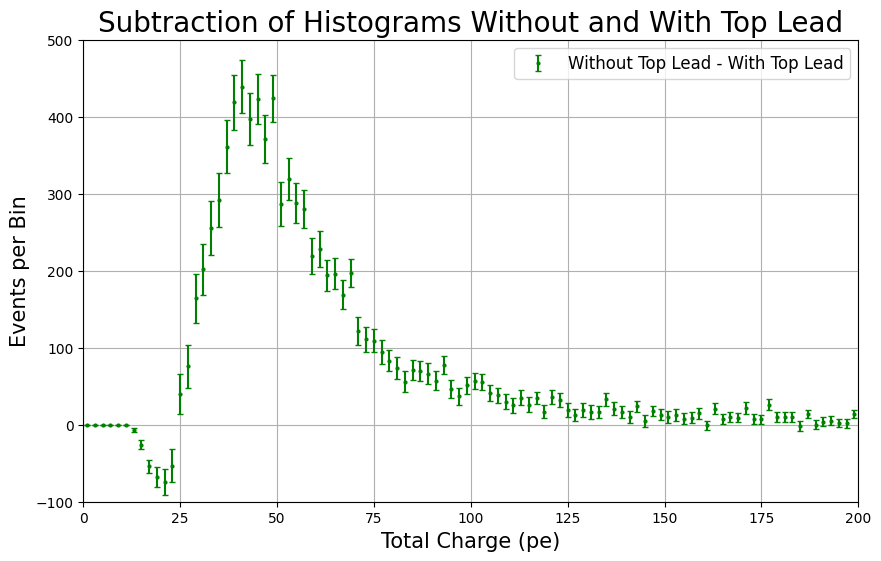

In [ ]:
#compare without top lead: 05/31/2024 and with top lead: 06/01/2025 data
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.optimize import curve_fit
from scipy.stats import moyal

def landau(x, a, loc, scale):
    return a * moyal.pdf(x, loc, scale)

time_no_top = "/raid1/genli/Data_D2O/M1_data/analysis_14977-14986_M1_20251119-175123/MASTER_RESULTS/total_time_length.json"
time_with_top = "/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251119-175339/MASTER_RESULTS/total_time_length.json"

with open(time_no_top, 'r') as f:
    t_no_top_data = json.load(f)
    t_no_top_sec = t_no_top_data['total_timelength_ns'] / 1e9

with open(time_with_top, 'r') as f:
    t_with_top_data = json.load(f)
    t_with_top_sec = t_with_top_data['total_timelength_ns'] / 1e9

print(f"Time without top lead: {t_no_top_sec:.2f} seconds")
print(f"Time with top lead: {t_with_top_sec:.2f} seconds")

file_no_top = '/raid1/genli/Data_D2O/M1_data/analysis_14977-14986_M1_20251118-163356_8tau/MASTER_RESULTS/aggregated_total_pe_M1.pkl'
file_with_top = '/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251118-001434_8tau/MASTER_RESULTS/aggregated_total_pe_M1.pkl'
data_no_top = np.load(file_no_top, allow_pickle=True)
data_with_top = np.load(file_with_top, allow_pickle=True)
centers_no_top = data_no_top['centers']
numpe_no_top = data_no_top['histograms']['Master Runs 14977-14986']
err_no_top = data_no_top['errors']['Master Runs 14977-14986']
centers_with_top = data_with_top['centers']
numpe_with_top = data_with_top['histograms']['Master Runs 23163-23172']
err_with_top = data_with_top['errors']['Master Runs 23163-23172']   
total_events_no_top = np.sum(numpe_no_top)
total_events_with_top = np.sum(numpe_with_top)
peakloc_no_top = centers_no_top[np.argmax(numpe_no_top)]
peakloc_with_top = centers_with_top[np.argmax(numpe_with_top)]
# print(data_no_top)
#Plotting the histograms for different dt cuts
plt.figure(figsize=(10, 6))
plt.errorbar(centers_no_top, numpe_no_top, yerr=err_no_top, fmt='o', label=f'Without Top Lead, Total Events: {total_events_no_top}, $\\bar{{f}} = {total_events_no_top/t_no_top_sec:.2f}$ Hz, Peak Loc: {peakloc_no_top} pe', color='red', markersize=2, capsize=2)
plt.errorbar(centers_with_top, numpe_with_top, yerr=err_with_top, fmt='x', label=f'With Top Lead, Total Events: {total_events_with_top}, $\\bar{{f}} = {total_events_with_top/t_with_top_sec:.2f}$ Hz, Peak Loc: {peakloc_with_top} pe', color='blue', markersize=2, capsize=2)
plt.title('Histograms Comparison Without and With Top Lead (10 runs each, 8$\\tau_\\mu$ $\\Delta t$ cut)', fontsize=18)
plt.xlabel('Total Charge (pe)', fontsize=15)
plt.ylabel('Events per Bin', fontsize=15)
# plt.yscale('log', base=10)
plt.xlim(0, 200)
plt.ylim(1, 1e3)
plt.legend(fontsize=12)
plt.grid()
plt.show()
#print runs numbers
print("Runs without top lead: 14977-14986")
print("Runs with top lead: 23163-23172")

#plotsubtraction histograms
y_sub = numpe_no_top - numpe_with_top
y_err_sub = np.sqrt(err_no_top**2 + err_with_top**2)

# Fit Landau
p0 = [np.max(y_sub)*20, centers_no_top[np.argmax(y_sub)], 10]
try:
    popt, pcov = curve_fit(landau, centers_no_top, y_sub, p0=p0, maxfev=10000)
except Exception as e:
    print(f"Fit failed: {e}")
    popt = None

plt.figure(figsize=(10, 6))
plt.errorbar(centers_no_top, y_sub, yerr=y_err_sub, fmt='o', label='Without Top Lead - With Top Lead', color='green', markersize=2, capsize=2)

if popt is not None:
    x_fit = np.linspace(0, 200, 1000)
    plt.plot(x_fit, landau(x_fit, *popt), 'k-', label=f'Landau Fit: MPV={popt[1]:.1f}, $\\sigma$={popt[2]:.1f}')

plt.title('Subtraction of Histograms Without and With Top Lead', fontsize=20)
plt.xlabel('Total Charge (pe)', fontsize=15)
plt.ylabel('Events per Bin', fontsize=15)
# plt.yscale('log', base=10)
plt.xlim(0, 200)
plt.ylim(-100, 500)
plt.legend(fontsize=12)
plt.grid()
plt.show()

TO DO:
1. dt plots: pe 10-25, pe 30-100, first try with top lead

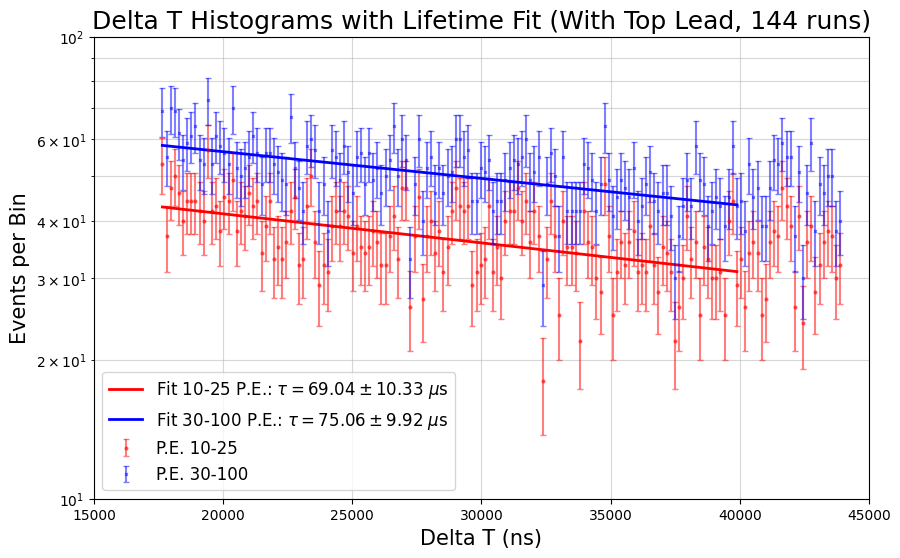

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

pe_10_25_wtop_dt_path = "/raid1/genli/Data_D2O/M1_data/analysis_23163-23354_M1_20251120-160317/MASTER_RESULTS/aggregated_delta_t_M1.pkl"
pe_30_100_wtop_dt_path = "/raid1/genli/Data_D2O/M1_data/analysis_23163-23354_M1_20251120-160450/MASTER_RESULTS/aggregated_delta_t_M1.pkl"

pe_10_25_wtop_dt = np.load(pe_10_25_wtop_dt_path, allow_pickle=True)
pe_30_100_wtop_dt = np.load(pe_30_100_wtop_dt_path, allow_pickle=True)
dt_centers_10_25 = pe_10_25_wtop_dt['centers']
dt_hist_10_25 = pe_10_25_wtop_dt['histograms']
dt_err_10_25 = pe_10_25_wtop_dt['errors']
dt_centers_30_100 = pe_30_100_wtop_dt['centers']
dt_hist_30_100 = pe_30_100_wtop_dt['histograms']
dt_err_30_100 = pe_30_100_wtop_dt['errors']

# Define fitting function (linear fit to log data)
def linear_fit(x, a, b):
    return a * x + b

def fit_and_get_tau(centers, counts, fit_window):
    mask = (centers >= fit_window[0]) & (centers <= fit_window[1]) & (counts > 0)
    x_data = centers[mask]
    y_data = np.log(counts[mask])
    
    popt, pcov = curve_fit(linear_fit, x_data, y_data)
    tau = -1 / popt[0]
    tau_err = tau**2 * np.sqrt(pcov[0][0])
    return x_data, popt, tau, tau_err

fit_window = (3000, 40000)

# Fit 10-25
counts_10_25 = dt_hist_10_25['Master Runs 23163-23354']
x_fit_1, popt_1, tau_1, tau_err_1 = fit_and_get_tau(dt_centers_10_25, counts_10_25, fit_window)

# Fit 30-100
counts_30_100 = dt_hist_30_100['Master Runs 23163-23354']
x_fit_2, popt_2, tau_2, tau_err_2 = fit_and_get_tau(dt_centers_30_100, counts_30_100, fit_window)

# Plot
plt.figure(figsize=(10, 6))

# Data 1
plt.errorbar(dt_centers_10_25, counts_10_25, yerr=dt_err_10_25['Master Runs 23163-23354'], 
             fmt='o', label='P.E. 10-25', color='red', markersize=2, capsize=2, alpha=0.5)
# Fit 1
plt.plot(x_fit_1, np.exp(linear_fit(x_fit_1, *popt_1)), 'r-', linewidth=2,
         label=f'Fit 10-25 P.E.: $\\tau={tau_1/1000:.2f} \\pm {tau_err_1/1000:.2f}$ $\\mu$s')

# Data 2
plt.errorbar(dt_centers_30_100, counts_30_100, yerr=dt_err_30_100['Master Runs 23163-23354'], 
             fmt='x', label='P.E. 30-100', color='blue', markersize=2, capsize=2, alpha=0.5)
# Fit 2
plt.plot(x_fit_2, np.exp(linear_fit(x_fit_2, *popt_2)), 'b-', linewidth=2,
         label=f'Fit 30-100 P.E.: $\\tau={tau_2/1000:.2f} \\pm {tau_err_2/1000:.2f}$ $\\mu$s')

plt.title('Delta T Histograms with Lifetime Fit (With Top Lead, 144 runs)', fontsize=18)
plt.xlabel('Delta T (ns)', fontsize=15)
plt.ylabel('Events per Bin', fontsize=15)
plt.yscale('log')
plt.xlim(15000, 45000)
plt.ylim(10, 100)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

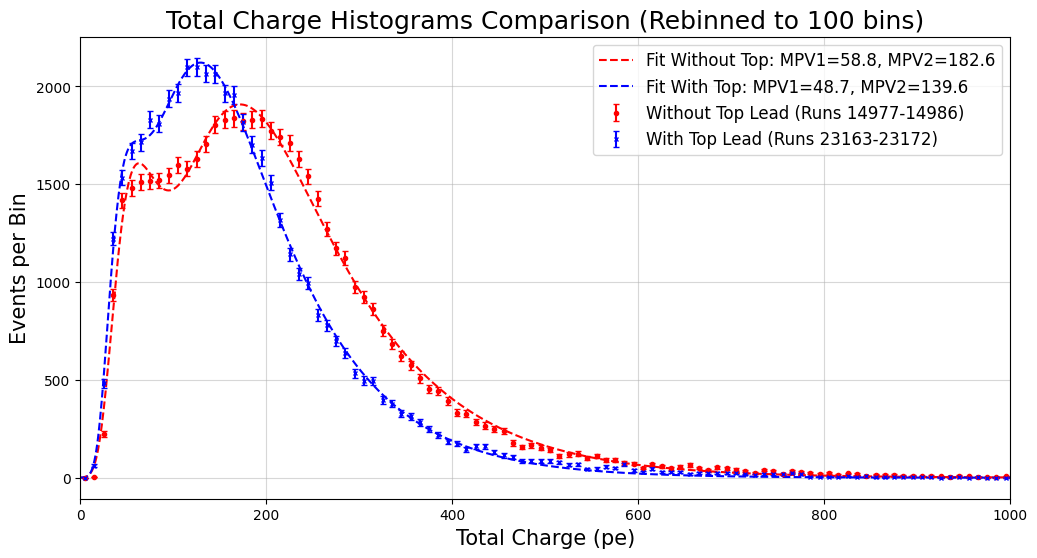

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import moyal
from scipy.signal import find_peaks

def rebin_histogram(centers, counts, errors, new_bin_edges):
    digitized = np.digitize(centers, new_bin_edges)
    new_counts = np.zeros(len(new_bin_edges) - 1)
    new_errors = np.zeros(len(new_bin_edges) - 1)
    new_centers = (new_bin_edges[:-1] + new_bin_edges[1:]) / 2
    
    for i in range(1, len(new_bin_edges)):
        mask = (digitized == i)
        if np.any(mask):
            new_counts[i-1] = np.sum(counts[mask])
            new_errors[i-1] = np.sqrt(np.sum(errors[mask]**2))
            
    return new_centers, new_counts, new_errors

def double_landau(x, a1, mpv1, eta1, a2, mpv2, eta2):
    return a1 * moyal.pdf(x, loc=mpv1, scale=eta1) + a2 * moyal.pdf(x, loc=mpv2, scale=eta2)

pehist_wo_top = "/raid1/genli/Data_D2O/M1_data/analysis_14977-14986_M1_20251124-161506/MASTER_RESULTS/aggregated_total_pe_M1.pkl"
pehist_w_top = "/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251124-161302/MASTER_RESULTS/aggregated_total_pe_M1.pkl"

# draw two histograms on the same plot
data_wo_top = np.load(pehist_wo_top, allow_pickle=True)
data_w_top = np.load(pehist_w_top, allow_pickle=True)
centers_wo_top = data_wo_top['centers']
numpe_wo_top = data_wo_top['histograms']['Master Runs 14977-14986']
err_wo_top = data_wo_top['errors']['Master Runs 14977-14986']
centers_w_top = data_w_top['centers']
numpe_w_top = data_w_top['histograms']['Master Runs 23163-23172']
err_w_top = data_w_top['errors']['Master Runs 23163-23172'] 

# Rebinning configuration
target_bins = 100
x_min, x_max = 0, 1000
new_bin_edges = np.linspace(x_min, x_max, target_bins + 1)

# Apply rebinning
centers_wo_top_rebin, numpe_wo_top_rebin, err_wo_top_rebin = rebin_histogram(centers_wo_top, numpe_wo_top, err_wo_top, new_bin_edges)
centers_w_top_rebin, numpe_w_top_rebin, err_w_top_rebin = rebin_histogram(centers_w_top, numpe_w_top, err_w_top, new_bin_edges)

# Helper to get initial guess
def get_initial_guess(x, y):
    dx = x[1] - x[0]
    total_area = np.sum(y) * dx
    
    # Find peaks
    peaks, properties = find_peaks(y, height=np.max(y)*0.2, distance=5)
    sorted_indices = np.argsort(properties['peak_heights'])[::-1]
    top_peaks = peaks[sorted_indices]
    
    mpv1_guess = x[np.argmax(y)]
    mpv2_guess = mpv1_guess * 1.5
    
    if len(top_peaks) >= 2:
        p1 = x[top_peaks[0]]
        p2 = x[top_peaks[1]]
        mpv1_guess = min(p1, p2)
        mpv2_guess = max(p1, p2)
    
    # a, mpv, eta
    return [total_area * 0.7, mpv1_guess, 20, total_area * 0.3, mpv2_guess, 40]

p0_wo = get_initial_guess(centers_wo_top_rebin, numpe_wo_top_rebin)
p0_w = get_initial_guess(centers_w_top_rebin, numpe_w_top_rebin)

bounds = (
    [0, 0, 1, 0, 0, 1],
    [np.inf, 1000, 200, np.inf, 1000, 200]
)

try:
    popt_wo, pcov_wo = curve_fit(double_landau, centers_wo_top_rebin, numpe_wo_top_rebin, p0=p0_wo, bounds=bounds, maxfev=20000)
except Exception as e:
    print(f"Fit failed for without top: {e}")
    popt_wo = None

try:
    popt_w, pcov_w = curve_fit(double_landau, centers_w_top_rebin, numpe_w_top_rebin, p0=p0_w, bounds=bounds, maxfev=20000)
except Exception as e:
    print(f"Fit failed for with top: {e}")
    popt_w = None

plt.figure(figsize=(12, 6))
plt.errorbar(centers_wo_top_rebin, numpe_wo_top_rebin, yerr=err_wo_top_rebin, fmt='o', label='Without Top Lead (Runs 14977-14986)', color='red', markersize=3, capsize=2)
plt.errorbar(centers_w_top_rebin, numpe_w_top_rebin, yerr=err_w_top_rebin, fmt='x', label='With Top Lead (Runs 23163-23172)', color='blue', markersize=3, capsize=2)

x_fit = np.linspace(x_min, x_max, 1000)
if popt_wo is not None:
    y_fit_wo = double_landau(x_fit, *popt_wo)
    plt.plot(x_fit, y_fit_wo, 'r--', label=f'Fit Without Top: MPV1={popt_wo[1]:.1f}, MPV2={popt_wo[4]:.1f}')
if popt_w is not None:
    y_fit_w = double_landau(x_fit, *popt_w)
    plt.plot(x_fit, y_fit_w, 'b--', label=f'Fit With Top: MPV1={popt_w[1]:.1f}, MPV2={popt_w[4]:.1f}')

plt.title(f'Total Charge Histograms Comparison (Rebinned to {target_bins} bins)', fontsize=18)
plt.xlabel('Total Charge (pe)', fontsize=15)
plt.ylabel('Events per Bin', fontsize=15)
# plt.yscale('log', base=10)
plt.xlim(x_min, x_max)
# plt.ylim(1, 3e2)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

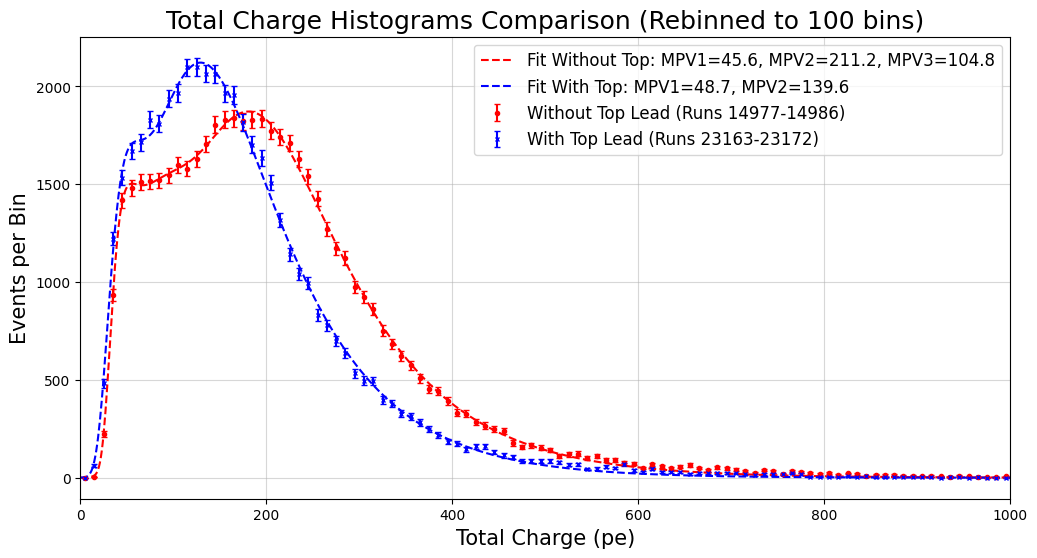

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import moyal
from scipy.signal import find_peaks

def rebin_histogram(centers, counts, errors, new_bin_edges):
    digitized = np.digitize(centers, new_bin_edges)
    new_counts = np.zeros(len(new_bin_edges) - 1)
    new_errors = np.zeros(len(new_bin_edges) - 1)
    new_centers = (new_bin_edges[:-1] + new_bin_edges[1:]) / 2
    
    for i in range(1, len(new_bin_edges)):
        mask = (digitized == i)
        if np.any(mask):
            new_counts[i-1] = np.sum(counts[mask])
            new_errors[i-1] = np.sqrt(np.sum(errors[mask]**2))
            
    return new_centers, new_counts, new_errors

def double_landau(x, a1, mpv1, eta1, a2, mpv2, eta2):
    return a1 * moyal.pdf(x, loc=mpv1, scale=eta1) + a2 * moyal.pdf(x, loc=mpv2, scale=eta2)

def triple_landau(x, a1, mpv1, eta1, a2, mpv2, eta2, a3, mpv3, eta3):
    return a1 * moyal.pdf(x, loc=mpv1, scale=eta1) + a2 * moyal.pdf(x, loc=mpv2, scale=eta2) + a3 * moyal.pdf(x, loc=mpv3, scale=eta3)

pehist_wo_top = "/raid1/genli/Data_D2O/M1_data/analysis_14977-14986_M1_20251124-161506/MASTER_RESULTS/aggregated_total_pe_M1.pkl"
pehist_w_top = "/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251124-161302/MASTER_RESULTS/aggregated_total_pe_M1.pkl"

# draw two histograms on the same plot
data_wo_top = np.load(pehist_wo_top, allow_pickle=True)
data_w_top = np.load(pehist_w_top, allow_pickle=True)
centers_wo_top = data_wo_top['centers']
numpe_wo_top = data_wo_top['histograms']['Master Runs 14977-14986']
err_wo_top = data_wo_top['errors']['Master Runs 14977-14986']
centers_w_top = data_w_top['centers']
numpe_w_top = data_w_top['histograms']['Master Runs 23163-23172']
err_w_top = data_w_top['errors']['Master Runs 23163-23172'] 

# Rebinning configuration
target_bins = 100
x_min, x_max = 0, 1000
new_bin_edges = np.linspace(x_min, x_max, target_bins + 1)

# Apply rebinning
centers_wo_top_rebin, numpe_wo_top_rebin, err_wo_top_rebin = rebin_histogram(centers_wo_top, numpe_wo_top, err_wo_top, new_bin_edges)
centers_w_top_rebin, numpe_w_top_rebin, err_w_top_rebin = rebin_histogram(centers_w_top, numpe_w_top, err_w_top, new_bin_edges)

# Helper to get initial guess
def get_initial_guess(x, y, n_peaks=3):
    dx = x[1] - x[0]
    total_area = np.sum(y) * dx
    
    # Find peaks
    peaks, properties = find_peaks(y, height=np.max(y)*0.2, distance=5)
    sorted_indices = np.argsort(properties['peak_heights'])[::-1]
    top_peaks = peaks[sorted_indices]
    
    mpv1_guess = x[np.argmax(y)]
    mpv2_guess = mpv1_guess * 1.5
    mpv3_guess = mpv1_guess * 2.0
    
    if len(top_peaks) >= 3:
        p1 = x[top_peaks[0]]
        p2 = x[top_peaks[1]]
        p3 = x[top_peaks[2]]
        ps = sorted([p1, p2, p3])
        mpv1_guess = ps[0]
        mpv2_guess = ps[1]
        mpv3_guess = ps[2]
    elif len(top_peaks) == 2:
        p1 = x[top_peaks[0]]
        p2 = x[top_peaks[1]]
        ps = sorted([p1, p2])
        mpv1_guess = ps[0]
        mpv2_guess = ps[1]
        mpv3_guess = mpv2_guess * 1.5
    
    if n_peaks == 3:
        # a, mpv, eta
        return [total_area * 0.5, mpv1_guess, 20, total_area * 0.3, mpv2_guess, 40, total_area * 0.2, mpv3_guess, 60]
    elif n_peaks == 2:
        return [total_area * 0.7, mpv1_guess, 20, total_area * 0.3, mpv2_guess, 40]
    else:
        return [total_area, mpv1_guess, 20]

p0_wo = get_initial_guess(centers_wo_top_rebin, numpe_wo_top_rebin, n_peaks=3)
p0_w = get_initial_guess(centers_w_top_rebin, numpe_w_top_rebin, n_peaks=2)

bounds_triple = (
    [0, 0, 1, 0, 0, 1, 0, 0, 1],
    [np.inf, 1000, 200, np.inf, 1000, 200, np.inf, 1000, 200]
)

bounds_double = (
    [0, 0, 1, 0, 0, 1],
    [np.inf, 1000, 200, np.inf, 1000, 200]
)

try:
    popt_wo, pcov_wo = curve_fit(triple_landau, centers_wo_top_rebin, numpe_wo_top_rebin, p0=p0_wo, bounds=bounds_triple, maxfev=20000)
except Exception as e:
    print(f"Fit failed for without top: {e}")
    popt_wo = None

try:
    popt_w, pcov_w = curve_fit(double_landau, centers_w_top_rebin, numpe_w_top_rebin, p0=p0_w, bounds=bounds_double, maxfev=20000)
except Exception as e:
    print(f"Fit failed for with top: {e}")
    popt_w = None

plt.figure(figsize=(12, 6))
plt.errorbar(centers_wo_top_rebin, numpe_wo_top_rebin, yerr=err_wo_top_rebin, fmt='o', label='Without Top Lead (Runs 14977-14986)', color='red', markersize=3, capsize=2)
plt.errorbar(centers_w_top_rebin, numpe_w_top_rebin, yerr=err_w_top_rebin, fmt='x', label='With Top Lead (Runs 23163-23172)', color='blue', markersize=3, capsize=2)

x_fit = np.linspace(x_min, x_max, 1000)
if popt_wo is not None:
    y_fit_wo = triple_landau(x_fit, *popt_wo)
    plt.plot(x_fit, y_fit_wo, 'r--', label=f'Fit Without Top: MPV1={popt_wo[1]:.1f}, MPV2={popt_wo[4]:.1f}, MPV3={popt_wo[7]:.1f}')
if popt_w is not None:
    y_fit_w = double_landau(x_fit, *popt_w)
    plt.plot(x_fit, y_fit_w, 'b--', label=f'Fit With Top: MPV1={popt_w[1]:.1f}, MPV2={popt_w[4]:.1f}')
plt.title(f'Total Charge Histograms Comparison (Rebinned to {target_bins} bins)', fontsize=18)
plt.xlabel('Total Charge (pe)', fontsize=15)
plt.ylabel('Events per Bin', fontsize=15)
# plt.yscale('log', base=10)
plt.xlim(x_min, x_max)
# plt.ylim(1, 3e2)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

Time without top lead: 35979.74 seconds
Time with top lead: 35969.96 seconds


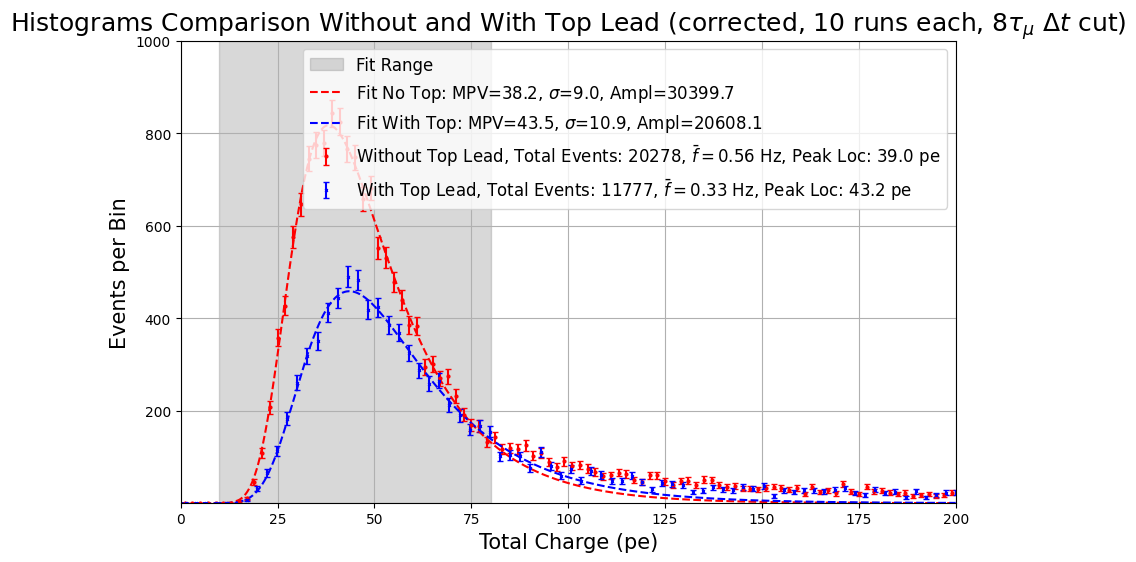

Runs without top lead: 14977-14986
Runs with top lead: 23163-23172


In [6]:
#compare without top lead: 05/31/2024 and with top lead: 06/01/2025 data
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.optimize import curve_fit
from scipy.stats import moyal

def landau(x, a, loc, scale):
    return a * moyal.pdf(x, loc, scale)

corrrect_ratio = 182.6/139.6

time_no_top = "/raid1/genli/Data_D2O/M1_data/analysis_14977-14986_M1_20251119-175123/MASTER_RESULTS/total_time_length.json"
time_with_top = "/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251119-175339/MASTER_RESULTS/total_time_length.json"

with open(time_no_top, 'r') as f:
    t_no_top_data = json.load(f)
    t_no_top_sec = t_no_top_data['total_timelength_ns'] / 1e9

with open(time_with_top, 'r') as f:
    t_with_top_data = json.load(f)
    t_with_top_sec = t_with_top_data['total_timelength_ns'] / 1e9

print(f"Time without top lead: {t_no_top_sec:.2f} seconds")
print(f"Time with top lead: {t_with_top_sec:.2f} seconds")

file_no_top = '/raid1/genli/Data_D2O/M1_data/analysis_14977-14986_M1_20251118-163356_8tau/MASTER_RESULTS/aggregated_total_pe_M1.pkl'
file_with_top = '/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251118-001434_8tau/MASTER_RESULTS/aggregated_total_pe_M1.pkl'
data_no_top = np.load(file_no_top, allow_pickle=True)
data_with_top = np.load(file_with_top, allow_pickle=True)
centers_no_top = data_no_top['centers']
numpe_no_top = data_no_top['histograms']['Master Runs 14977-14986']
err_no_top = data_no_top['errors']['Master Runs 14977-14986']
centers_with_top = data_with_top['centers'] * corrrect_ratio
numpe_with_top = data_with_top['histograms']['Master Runs 23163-23172']
err_with_top = data_with_top['errors']['Master Runs 23163-23172']   
total_events_no_top = np.sum(numpe_no_top)
total_events_with_top = np.sum(numpe_with_top)
peakloc_no_top = centers_no_top[np.argmax(numpe_no_top)]
peakloc_with_top = centers_with_top[np.argmax(numpe_with_top)]

# Define fit range
fit_range = (10, 80)

# Fit Landau for no top
mask_no = (centers_no_top >= fit_range[0]) & (centers_no_top <= fit_range[1])
p0_no_top = [np.max(numpe_no_top[mask_no])*20, centers_no_top[mask_no][np.argmax(numpe_no_top[mask_no])], 10]
try:
    popt_no_top, _ = curve_fit(landau, centers_no_top[mask_no], numpe_no_top[mask_no], p0=p0_no_top, maxfev=10000)
except Exception as e:
    print(f"Fit failed for no top: {e}")
    popt_no_top = None

# Fit Landau for with top
mask_with = (centers_with_top >= fit_range[0]) & (centers_with_top <= fit_range[1])
p0_with_top = [np.max(numpe_with_top[mask_with])*20, centers_with_top[mask_with][np.argmax(numpe_with_top[mask_with])], 10]
try:
    popt_with_top, _ = curve_fit(landau, centers_with_top[mask_with], numpe_with_top[mask_with], p0=p0_with_top, maxfev=10000)
except Exception as e:
    print(f"Fit failed for with top: {e}")
    popt_with_top = None

# Plotting the histograms for different dt cuts
plt.figure(figsize=(10, 6))
plt.errorbar(centers_no_top, numpe_no_top, yerr=err_no_top, fmt='o', label=f'Without Top Lead, Total Events: {total_events_no_top}, $\\bar{{f}} = {total_events_no_top/t_no_top_sec:.2f}$ Hz, Peak Loc: {peakloc_no_top:.1f} pe', color='red', markersize=2, capsize=2)
plt.errorbar(centers_with_top, numpe_with_top, yerr=err_with_top, fmt='x', label=f'With Top Lead, Total Events: {total_events_with_top}, $\\bar{{f}} = {total_events_with_top/t_with_top_sec:.2f}$ Hz, Peak Loc: {peakloc_with_top:.1f} pe', color='blue', markersize=2, capsize=2)
plt.axvspan(fit_range[0], fit_range[1], color='gray', alpha=0.3, label='Fit Range')
x_fit = np.linspace(0, 200, 1000)
if popt_no_top is not None:
    plt.plot(x_fit, landau(x_fit, *popt_no_top), 'r--', label=f'Fit No Top: MPV={popt_no_top[1]:.1f}, $\\sigma$={popt_no_top[2]:.1f}, Ampl={popt_no_top[0]:.1f}')
if popt_with_top is not None:
    plt.plot(x_fit, landau(x_fit, *popt_with_top), 'b--', label=f'Fit With Top: MPV={popt_with_top[1]:.1f}, $\\sigma$={popt_with_top[2]:.1f}, Ampl={popt_with_top[0]:.1f}')

plt.title('Histograms Comparison Without and With Top Lead (corrected, 10 runs each, 8$\\tau_\\mu$ $\\Delta t$ cut)', fontsize=18)
plt.xlabel('Total Charge (pe)', fontsize=15)
plt.ylabel('Events per Bin', fontsize=15)
# plt.yscale('log', base=10)
plt.xlim(0, 200)
plt.ylim(1, 1e3)
plt.legend(fontsize=12)
plt.grid()
plt.show()
#print runs numbers
print("Runs without top lead: 14977-14986")
print("Runs with top lead: 23163-23172")